## Predicting All Cause Hospital Readmissions Using NLP Enhanced EHR Data and Cox Survival Models

## Code Attribution
<ul>
  <li> Title: os.path -- Common pathname manipulations
  <li> Author: Python
  <li> Date: 22 May 2026
  <li> Modified By: Charlotte Alley
  <li> Description: This module implements some useful functions on pathnames.

## Code Attribution
<ul>
  <li> Title: subprocess -- Subprocess management
  <li> Author: Python
  <li> Date: 22 May 2026
  <li> Modified By: Charlotte Alley
  <li> Description: The subprocess module allows you to spawn new processes, connect to their input/output/error pipes, and obtain their return codes.

## Code Attribution
<ul>
  <li> Title: pandas.merge_asof
  <li> Author: Pandas
  <li> Date: 22 May 2026
  <li> Modified By: Charlotte Alley
  <li> Description: This is similar to a left-join except that we match on nearest key rather than equal keys. Both DataFrames must be first sorted by the merge key in ascending order before calling this function. Sorting by any additional ‘by’ grouping columns is not required.

## Setup

In [61]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from ydata_profiling import ProfileReport
import os
from zipfile import ZipFile
import subprocess
import re
import torch
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sksurv.util import Surv
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import cumulative_dynamic_auc, integrated_brier_score
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

## Extract CSV files from ZIP Files
In order to extract the CSV files from the ZIP files, I used the os library to navigate and manage the computer's file system, and the subprocess library to step outside of Python and run the operating system's native terminal commands directly from the code. While this process can be completed manually with two zip files, a script is necessary for scalability and reproducability. 

In [2]:
# Defines primary directory to store extracted data 
out_dir = "extracted_ehr_data"

# Creates main storage directory, handles pre-existing directory
os.makedirs(out_dir, exist_ok=True)

# Lists specific ZIP archives that need extracting
zip_files = ["synthea-patient-pop1-csv.zip", "synthea-patient-pop2-csv.zip"] 

# Establishes root output path for loop to reference
base_out_dir = "extracted_ehr_data"

# Processes ZIP files one by one
for zip_file in zip_files:
    # Verifies if the current ZIP file exists on the disk 
    if not os.path.exists(zip_file):
        # Handles missing files 
        print(f"Error: Cannot find file at {zip_file}")
        continue
        
    # Gets file name without the '.zip' extension
    folder_name = os.path.splitext(os.path.basename(zip_file))[0]
    
    # Creates a unique path 
    unique_out_dir = os.path.join(base_out_dir, folder_name)
    os.makedirs(unique_out_dir, exist_ok=True)

    # Logs start of extraction for visibility
    print(f"Extracting {zip_file} into {unique_out_dir}...")
    
    # Runs unzip command, overwriting existing files (-o), suppressing output (-q), and 
    # setting the target directory (-d)
    subprocess.run(["unzip", "-o", "-q", zip_file, "-d", unique_out_dir], check=True)
    
    # Confirms successful extraction
    print("Files have been extracted")

Extracting synthea-patient-pop1-csv.zip into extracted_ehr_data/synthea-patient-pop1-csv...
Files have been extracted
Extracting synthea-patient-pop2-csv.zip into extracted_ehr_data/synthea-patient-pop2-csv...
Files have been extracted


## Create Master Dataframe
Now that the CSV files have been extracted, the next step is to combine the extracted CSV files to create a master dataframe. I used the os library again to construct the paths and verify that matching files exist across both population folders. I used pandas to read in the CSV's, vertically stack their rows into a unified dataset, and to store them in a structured dictionary. In order to filter through the raw data to only include relevant information for both the NLP and the Cox model, I standardized the column names to lowercase to create smoother merging conditions. Filtering the master dataset to include only rows where encounterclass == 'inpatient' creates the baseline spine for the Cox Model, establishing 103,223 true hospital admissions. The procedure text descriptions were then pre-grouped and combined into a single semicolon-delimited string per unique encounter identifier. pd.merge_asof was used to scan backward in time to dynamically capture a patient's complete running history of pre-existing conditions up to their admission day, helping to fill the mostly blank description_condition column with meaningful information to build the model upon.

In [3]:
# Defines paths to previously created directories
folder_pop1 = "extracted_ehr_data/synthea-patient-pop1-csv"
folder_pop2 = "extracted_ehr_data/synthea-patient-pop2-csv"

# Isolates the four essential CSV files needed for the Cox MVP model
target_csvs = [
    "patients.csv",       # Constant demographic baseline features
    "conditions.csv",     # Text descriptions for NLP features
    "encounters.csv",     # Timeline intervals (Baseline discharge vs readmission event)
    "procedures.csv"      # Supplemental intervention text for NLP features
]

# Initializes dictionary to hold master df's
master_dfs = {}

# Constructs paths for target file in both population folders 
for file_name in target_csvs:
    path1 = os.path.join(folder_pop1, file_name)
    path2 = os.path.join(folder_pop2, file_name)
    
    # Checks if the file exists in both folders before trying to combine
    if os.path.exists(path1) and os.path.exists(path2):
        print(f"Combining {file_name}...")

        # Reads CSV's into memory as dataframes
        df1 = pd.read_csv(path1)
        df2 = pd.read_csv(path2)
        
        # Cleans name by dropping .csv extension
        table_key = file_name.replace(".csv", "")  
        
        # Vertically stacks rows of df2 beneath df1, resets index row numbers
        combined_df = pd.concat([df1, df2], ignore_index=True)
        
        # Standardizes all column names to lowercase 
        combined_df.columns = combined_df.columns.str.lower()
        
        # Saves combined df in dictionary with cleaned name as lookup key
        master_dfs[table_key] = combined_df
        
        print(f"Total rows in master {table_key}: {len(master_dfs[table_key])}")
    else:
        print(f"Skipping {file_name}: Missing in one of the directories.")

print("Stacking completed.")

Combining patients.csv...
Total rows in master patients: 30945
Combining conditions.csv...
Total rows in master conditions: 1738061
Combining encounters.csv...
Total rows in master encounters: 2733207
Combining procedures.csv...
Total rows in master procedures: 4880491
Stacking completed.


In [16]:
# Grabs four stacked CSV's from the master dictionary to define the variables
df_encounters = master_dfs["encounters"]
df_patients = master_dfs["patients"]
df_conditions = master_dfs["conditions"]
df_procedures = master_dfs["procedures"]

# Converts all timeline columns to datetime objects and strips time-zone markers
df_encounters["start"] = pd.to_datetime(df_encounters["start"]).dt.tz_localize(None)
df_encounters["stop"] = pd.to_datetime(df_encounters["stop"]).dt.tz_localize(None)
df_conditions["start"] = pd.to_datetime(df_conditions["start"]).dt.tz_localize(None)
df_procedures["start"] = pd.to_datetime(df_procedures["start"]).dt.tz_localize(None)

# Filters encounters df to only include true inpatient hospital admissions
df_inpatient_encounters = df_encounters[df_encounters["encounterclass"] == "inpatient"].copy()

# Sort the conditions table chronologically to ensure history stacks correctly
df_conditions_sorted = df_conditions.dropna(subset=["description"]).sort_values("start")

# Builds a running list of historical diagnoses over time
df_conditions_sorted["running_history"] = (
    df_conditions_sorted.groupby("patient")["description"]
    .transform(lambda x: ["; ".join(x.iloc[:i+1].unique()) for i in range(len(x))])
)

# Keeps only the latest historical text snapshot for any given patient-timestamp combo
df_cond_history_spine = (
    df_conditions_sorted.drop_duplicates(subset=["patient", "start"], keep="last")
    [["patient", "start", "running_history"]]
)

# Shifts encounter start times back by 1 minute to create firewall against 
# identical checkout timestamps
df_inpatient_encounters["history_cutoff_time"] = df_inpatient_encounters["start"] - pd.Timedelta(minutes=1)

In [17]:
# Sorts spines chronologically before running the specialized asof merge
df_inpatient_encounters = df_inpatient_encounters.sort_values("history_cutoff_time")
df_cond_history_spine = df_cond_history_spine.sort_values("start")

# Links hospital cutoff times to past medical history
df_master = pd.merge_asof(
    df_inpatient_encounters,
    df_cond_history_spine,
    left_on="history_cutoff_time",
    right_on="start",
    by="patient",
    direction="backward"
)

# Fixes naming overlap caused by multi-column merge alignment and sets clean id key
df_master = df_master.rename(columns={"start_x": "start", "id": "id_encounter"}).drop(columns=["start_y"], errors="ignore")

# Base demographic merge to set up constant baseline traits
df_master = pd.merge(
    df_master, 
    df_patients, 
    left_on="patient", 
    right_on="id", 
    how="inner",
    suffixes=("_encounter", "_patient")
)

# Groups procedures by encounter to combine multiple descriptions into one string
df_procedures_grouped = (
    df_procedures.dropna(subset=["description"])
    .groupby("encounter")["description"]
    .apply(lambda x: "; ".join(x.unique()))
    .reset_index()
    .rename(columns={"description": "description_procedure"})
)

# Pulls in interventional text from pre-grouped procedures df using lowercase keys
df_master = pd.merge(
    df_master, 
    df_procedures_grouped, 
    left_on="id_encounter", 
    right_on="encounter", 
    how="left"
)

# Cleans up column names to match original target modeling structure
df_master = df_master.rename(columns={"running_history": "description_condition"})
df_master = df_master.drop(columns=["encounter", "history_cutoff_time"], errors="ignore")

In [18]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103223 entries, 0 to 103222
Data columns (total 42 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   id_encounter           103223 non-null  object        
 1   start                  103223 non-null  datetime64[ns]
 2   stop                   103223 non-null  datetime64[ns]
 3   patient                103223 non-null  object        
 4   organization           103223 non-null  object        
 5   provider               103223 non-null  object        
 6   payer                  103223 non-null  object        
 7   encounterclass         103223 non-null  object        
 8   code                   103223 non-null  int64         
 9   description            103223 non-null  object        
 10  base_encounter_cost    103223 non-null  float64       
 11  total_claim_cost       103223 non-null  float64       
 12  payer_coverage         103223 non-null  floa

## Handle Missingness & DType Conversions Prior to EDA
After the creation of the master dataframe, there were clearly redundant columns that wouldn't be contributing anything novel to the model. Since all of the filtered rows are encounterclass == 'inpatient', this column has become redundant and was removed. Since lat and lon (of the patient's current address) have been included and have no missing values, I chose to remove all other geographic identifiers except for birthplace. The id_patient was a duplicate of patient, and was dropped as well. When dealing with EHR data, missingness is usually meaningful, so any imputations completed reflected the meaningfulness of that missingness. For example, if the marital status was missing, it was imputed with 'unknown' rather than imputed with the median status. deathdate is the only column that has been left with NaN values, because it will need to be handled as a censor for the Cox Model. Features were then converted to datatypes that would either reduce their storage or aid in the creation of the NLP.

In [19]:
# Drops identification numbers, names, addresses, redundant patient IDs, 
# uniform encounter classes, and high-missingness geographic strings
columns_to_drop = ["ssn", "drivers", "passport", "prefix", "first", "last", 
                   "suffix", "maiden", "zip", "city", "state", "county", 
                   "address", "id_patient", "encounterclass", "id"]
df_master = df_master.drop(columns=columns_to_drop, errors="ignore")

# Fills missing text features with placeholders to prevent NLP tokenizer crashes
df_master["description_procedure"] = df_master["description_procedure"].fillna("no procedures recorded")
df_master["description_condition"] = df_master["description_condition"].fillna("no conditions recorded")

# Imputes missing administrative and clinical text fields with custom placeholders
df_master["reasondescription"] = df_master["reasondescription"].fillna("reason unknown")
df_master["marital"] = df_master["marital"].fillna("unknown")

# Maps missing numerical reason codes to a string placeholder to ensure clean categorical behavior
df_master["reasoncode"] = df_master["reasoncode"].astype(str).replace("nan", "no_acute_trigger")

# Converts vital demographic timeline columns into true datetime objects for modeling math
df_master["birthdate"] = pd.to_datetime(df_master["birthdate"]).dt.tz_localize(None)
df_master["deathdate"] = pd.to_datetime(df_master["deathdate"]).dt.tz_localize(None)

# Converts repetitive operational text tracking columns and reason codes into efficient categorical data types
categorical_cols = ["marital", "race", "ethnicity", "gender", "birthplace", 
                    "organization", "provider", "payer", "reasoncode"]
for col in categorical_cols:
    df_master[col] = df_master[col].astype("category")

# Converts raw medical description text columns to explicit string data types for NLP processing
text_cols = ["description", "description_condition", "description_procedure", "reasondescription"]
for col in text_cols:
    df_master[col] = df_master[col].astype("string")

In [20]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103223 entries, 0 to 103222
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   id_encounter           103223 non-null  object        
 1   start                  103223 non-null  datetime64[ns]
 2   stop                   103223 non-null  datetime64[ns]
 3   patient                103223 non-null  object        
 4   organization           103223 non-null  category      
 5   provider               103223 non-null  category      
 6   payer                  103223 non-null  category      
 7   code                   103223 non-null  int64         
 8   description            103223 non-null  string        
 9   base_encounter_cost    103223 non-null  float64       
 10  total_claim_cost       103223 non-null  float64       
 11  payer_coverage         103223 non-null  float64       
 12  reasoncode             103223 non-null  cate

In [21]:
# Converts repetitive operational text tracking columns into efficient categorical data types
categorical_cols = ["marital", "race", "ethnicity", "gender", "birthplace", 
                    "organization", "provider", "payer"]
for col in categorical_cols:
    df_master[col] = df_master[col].astype("category")

# Converts raw medical description text columns to explicit string data types for NLP processing
text_cols = ["description", "description_condition", "description_procedure", "reasondescription"]
for col in text_cols:
    df_master[col] = df_master[col].astype("string")

# Verifies your complete updated data types list
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103223 entries, 0 to 103222
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   id_encounter           103223 non-null  object        
 1   start                  103223 non-null  datetime64[ns]
 2   stop                   103223 non-null  datetime64[ns]
 3   patient                103223 non-null  object        
 4   organization           103223 non-null  category      
 5   provider               103223 non-null  category      
 6   payer                  103223 non-null  category      
 7   code                   103223 non-null  int64         
 8   description            103223 non-null  string        
 9   base_encounter_cost    103223 non-null  float64       
 10  total_claim_cost       103223 non-null  float64       
 11  payer_coverage         103223 non-null  float64       
 12  reasoncode             103223 non-null  cate

## EDA with ydata_profiling
The report revealed that three of the columns have high cardinality, a feature that once one-hot-encoded can lead to overfitting. Features must be fed into the Cox Model as numerical inputs, so keeping these three columns (provider, organization, and birthplace) as is, will create hundreds of features. Since this project is focused more on the text embeddings created from using NLP on the descriptions, I decided to remove the high cardinality columns. Since multicollinearity can disrupt a Cox Model, I also decided to remove enough columns from the high correlation alerts to remove the alert, reducing redundancy within the master dataframe. When it comes to imbalance, the Cox Model is fairly robust. The description imbalance will be removed once NLP is used to extract (and PCA to compress) the embeddings, so I will ignore that feature for now. As for marital and race, the value for both with the least values still has a large number of values, so I will be leaving the imbalance for those features (Although, it was interesting to note the higher percentage of Hawaiians in this simulated population than is normally seen on average. I've read that the sythentic populations are often based on Boston, MA, in which this percentage is accurate). The skew alert for the code feature will be irrelevant (I am already planning on dropping this column due to the high correlation), and the zeroes detected are meaningful, so I will be leaving those untouched. 

In [22]:
# Report has been commented out to avoid unnecessary compute 
# EHR_report.to_file("EHR_report.html")
# EHR_report = ProfileReport(df_master, title='EHR Report')

In [23]:
# Drops high-cardinality features and highly correlated billing/financial columns 
# flagged by ydata_profiling to prevent model instability
profiling_drops = ["organization", "provider", "birthplace", "code", 
                   "base_encounter_cost", "healthcare_coverage", 
                   "healthcare_expenses"]
df_master = df_master.drop(columns=profiling_drops, errors="ignore")

In [24]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103223 entries, 0 to 103222
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   id_encounter           103223 non-null  object        
 1   start                  103223 non-null  datetime64[ns]
 2   stop                   103223 non-null  datetime64[ns]
 3   patient                103223 non-null  object        
 4   payer                  103223 non-null  category      
 5   description            103223 non-null  string        
 6   total_claim_cost       103223 non-null  float64       
 7   payer_coverage         103223 non-null  float64       
 8   reasoncode             103223 non-null  category      
 9   reasondescription      103223 non-null  string        
 10  description_condition  103223 non-null  string        
 11  birthdate              103223 non-null  datetime64[ns]
 12  deathdate              75648 non-null   date

## NLP Feature Engineering 
I have used the sentence_transformer library before, but never on a dataset this large. Because a lot of the descriptions contain identical information (due to the dataset being sythesized and similar diagnoses existing across multiple patients), I filtered out the duplicates to reduce computational overhead, and mapped the embeddings back onto the original dataframe. The model is the most computationally expensive portion of the project thus far. For every narrative, the model has to tokenize the text, convert the tokens to embeddings, and pass them through the multiple transformation layers. 

In [25]:
# Cleans overlapping active diagnoses and post-surgical leakages from past history strings
def remove_active_day_leakage(row):
    history = str(row["description_condition"])
    trigger = str(row["reasondescription"])
    
    if pd.isna(row["description_condition"]) or history == "no conditions recorded" or history == "<NA>":
        return "no prior conditions recorded"
        
    # Dynamically strips the active primary trigger from the historical text list
    if trigger != "reason unknown":
        history = re.sub(rf'\b{re.escape(trigger)}\b', '', history, flags=re.IGNORECASE)
    
    # Cleans up double semicolons or trailing punctuation left behind by string deletions
    history = re.sub(r';\s*;', ';', history)
    history = history.strip("; ").strip()
    
    return history if history else "no prior conditions recorded"

# Applies text firewall and fuses the four components into a single clean narrative
df_master["clean_history"] = df_master.apply(remove_active_day_leakage, axis=1)
df_master["clinical_narrative"] = (
    "Encounter type: " + df_master["description"] + 
    ". Primary trigger: " + df_master["reasondescription"] + 
    ". Historical comorbidities: " + df_master["clean_history"] + 
    ". Procedures performed: " + df_master["description_procedure"] + "."
)

# Drops intermediate text cleaning column to maintain a pristine matrix layout
df_master = df_master.drop(columns=["clean_history"], errors="ignore")

In [26]:
# Initializes model
model = SentenceTransformer('all-MiniLM-L6-v2')  

# Isolates unique clinical narrative text strings to prevent redundant CPU calculations
unique_narratives = df_master["clinical_narrative"].drop_duplicates().tolist()
print(f"Total rows to map: {len(df_master)} | Unique narratives to encode: {len(unique_narratives)}")

# Generates numerical embeddings for only the unique sentences using local CPU threads
print("Encoding unique narratives via Hugging Face...")
unique_embeddings = model.encode(
    unique_narratives, 
    batch_size=64, 
    show_progress_bar=True, 
    convert_to_numpy=True
)

# Maps the calculated embedding vectors back to a lookup dictionary using text keys
embedding_lookup = dict(zip(unique_narratives, unique_embeddings))

# Broadcasts the unique vectors back into a comprehensive matrix matching 103K master rows
print("Mapping vectors back to master dataframe...")
nlp_features = np.stack(df_master["clinical_narrative"].map(embedding_lookup).values)

# Verifies final high-dimensional NLP matrix layout
print(f"\nFinal Feature Matrix Shape: {nlp_features.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total rows to map: 103223 | Unique narratives to encode: 38607
Encoding unique narratives via Hugging Face...


Batches:   0%|          | 0/604 [00:00<?, ?it/s]

Mapping vectors back to master dataframe...

Final Feature Matrix Shape: (103223, 384)


## PCA on Text Embeddings
After the 38607 unique narratives have been transformed into sentence embeddings, PCA was applied to reduce the 384-dimensional embedding space to 66 principal components, preserving 95% of the variance. PCA was applied to the full embedding matrix prior to train/test splitting due to computational constraints. Because PCA is unsupervised and does not use the readmission outcome, the risk of target leakage is limited; however, future work should fit PCA only on the training set and apply the learned transformation to the test set.

In [27]:
# Standardizes features for PCA 
scaler = StandardScaler()
nlp_features_scaled = scaler.fit_transform(nlp_features)

# Initializes PCA,explaining 95% of variance
pca = PCA(n_components=0.95)  
nlp_features_pca = pca.fit_transform(nlp_features_scaled)

print(f"Original dimensions: {nlp_features.shape[1]}")
print(f"Reduced dimensions: {nlp_features_pca.shape[1]}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.3f}")

Original dimensions: 384
Reduced dimensions: 66
Explained variance ratio: 0.950


In [28]:
# Converts PCA results to dataframe with meaningful column names
pca_columns = [f'pca_{i+1}' for i in range(nlp_features_pca.shape[1])]
df_pca = pd.DataFrame(nlp_features_pca, columns=pca_columns)

# Resets index to ensure proper alignment
df_pca = df_pca.reset_index(drop=True)
df_master = df_master.reset_index(drop=True)

# Merges PCA features with master dataframe
df_master_with_pca = pd.concat([df_master, df_pca], axis=1)

# Removes raw text columns now represented by PCA embeddings
pca_drops = [
    "description",
    "reasondescription",
    "description_condition",
    "description_procedure",
    "clinical_narrative"
]

df_master_with_pca = df_master_with_pca.drop(
    columns=pca_drops,
    errors="ignore"
)

# Verifies the merge worked correctly
print(f"Original df_master shape: {df_master.shape}")
print(f"PCA features shape: {df_pca.shape}")
print(f"Merged dataframe shape: {df_master_with_pca.shape}")
print(f"New PCA columns: {pca_columns[:5]}...") 

Original df_master shape: (103223, 21)
PCA features shape: (103223, 66)
Merged dataframe shape: (103223, 82)
New PCA columns: ['pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5']...


## Duration, Event and Covariates Definitions
When creating a Cox Model, duration refers to the time until the event or the censoring. The event, in this case, is hospital readmission. The covariates are the predictors or features (PCA features, demographics and financial variables in this case). Initially, I had planned to keep the mortality data, but I ended up dropping the deathdate feature, as this model is focused on readmission as the primary event, and treated death as a seperate clinical outcome. Future work could extend this framework using competing risks survival models. The final survival dataset was collapsed to one row per patient. The first inpatient encounter was treated as the baseline encounter, and the event was defined as readmission within 30 days after discharge from that baseline encounter. NLP-derived PCA features represent the content of the baseline encounter narrative. The final dataframe contains 11792 patients, with an event rate of 8.5%, meaning that 8.5% of the population were readmitted within 30 days of getting dishcharged. 

In [37]:
# Sorts encounters chronologically within each patient
df_sorted = df_master_with_pca.sort_values(["patient", "start"]).copy()

# Defines baseline row as first inpatient encounter per patient
df_survival = (
    df_sorted
    .groupby("patient", as_index=False)
    .first()
)

# Defines second inpatient admission start date per patient
second_admission = (
    df_sorted
    .groupby("patient")
    .nth(1)
    .reset_index()[["patient", "start"]]
    .rename(columns={"start": "next_start"})
)

# Merges second admission date onto baseline patient-level dataframe
df_survival = df_survival.merge(
    second_admission,
    on="patient",
    how="left"
)

# Time from first discharge to second inpatient admission
df_survival["time_to_readmit"] = (
    df_survival["next_start"] - df_survival["stop"]
).dt.days

# Defines event as readmission within 30 days
df_survival["event"] = (
    (df_survival["time_to_readmit"] >= 0) &
    (df_survival["time_to_readmit"] <= 30)
).astype(int)

# Censors non-events at 30 days
df_survival["time_to_readmit"] = df_survival["time_to_readmit"].where(
    df_survival["event"] == 1,
    30
)

# Removes possibility of negative durations
df_survival = df_survival[df_survival["time_to_readmit"] >= 0].copy()

# Defines age at baseline encounter
df_survival["age"] = (
    (df_survival["start"] - df_survival["birthdate"])
    .dt.days / 365.25
)

# Drops deathdate and next_start features
df_survival = df_survival.drop(columns=["deathdate", "next_start"], errors="ignore")

# Prints verification of variables altered and created
print(df_survival[[
    "patient", "start", "stop", "time_to_readmit", "event", "age"
]].head())

print("\nFinal patient-level survival shape:", df_survival.shape)
print("Unique patients:", df_survival["patient"].nunique())
print("Event rate:", df_survival["event"].mean().round(3))

                                patient               start  \
0  0005b429-ed45-a435-fc39-4f395cf5833a 1993-05-29 19:12:19   
1  0007efd3-c50d-7e51-6a30-8dc08d4269fc 2021-01-05 08:05:10   
2  000eba84-0d5c-2657-0b5e-0c70f2f746c2 2021-04-19 01:41:09   
3  002ba0b7-6708-9c6f-741c-0c3934957366 2016-09-02 09:08:47   
4  002bc307-2fff-04ba-161b-98cce123e226 2012-01-19 19:30:33   

                 stop  time_to_readmit  event        age  
0 1993-05-30 19:12:19             30.0      0  64.386037  
1 2021-01-15 08:24:20             30.0      0  57.114305  
2 2021-04-20 01:41:09             30.0      0  92.035592  
3 2016-09-03 09:08:47             30.0      0  31.797399  
4 2012-01-20 19:30:33             30.0      0  78.433949  

Final patient-level survival shape: (11792, 84)
Unique patients: 11792
Event rate: 0.085


## Train Test Split

In [41]:
# Train/test split
train_df, test_df = train_test_split(
    df_survival,
    test_size=0.2,
    random_state=0,
    stratify=df_survival["event"]
)

# Defines columns that shouldn't be used for prediction
drop_cols = [
    "id_encounter",
    "patient",
    "start",
    "stop",
    "birthdate",
    "time_to_readmit",
    "event"
]

# Creates X matrices
X_train = train_df.drop(columns=drop_cols, errors="ignore")
X_test = test_df.drop(columns=drop_cols, errors="ignore")

# One-hot encodes categoricals
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Aligns test columns to train columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Keeps y as regular df columns for now
y_train_df = train_df[["event", "time_to_readmit"]].copy()
y_test_df = test_df[["event", "time_to_readmit"]].copy()

# Verify
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain event rate:")
print(y_train_df["event"].value_counts(normalize=True))

print("\nTest event rate:")
print(y_test_df["event"].value_counts(normalize=True))

print("\nMissing values in X_train:", X_train.isna().sum().sum())
print("Missing values in X_test:", X_test.isna().sum().sum())

Train shape: (9433, 84)
Test shape: (2359, 84)

X_train shape: (9433, 114)
X_test shape: (2359, 114)

Train event rate:
event
0    0.914555
1    0.085445
Name: proportion, dtype: float64

Test event rate:
event
0    0.914794
1    0.085206
Name: proportion, dtype: float64

Missing values in X_train: 0
Missing values in X_test: 0


In [42]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("Missing values in X_train_scaled:", X_train_scaled.isna().sum().sum())
print("Missing values in X_test_scaled:", X_test_scaled.isna().sum().sum())

X_train_scaled shape: (9433, 114)
X_test_scaled shape: (2359, 114)
Missing values in X_train_scaled: 0
Missing values in X_test_scaled: 0


In [43]:
# Saves results to pickle file to avoid running NLP, again
df_survival.to_pickle("df_survival_with_pca.pkl")
X_train.to_pickle("X_train.pkl")
X_test.to_pickle("X_test.pkl")
X_train_scaled.to_pickle("X_train_scaled.pkl")
X_test_scaled.to_pickle("X_test_scaled.pkl")
y_train_df.to_pickle("y_train_df.pkl")
y_test_df.to_pickle("y_test_df.pkl")

## Fitting the Cox Model & Evaluation Metrics
The penalized Cox model achieved a train C-index of 0.947 and a test C-index of 0.931, indicating strong discrimination on unseen patients. The Integrated Brier Score was 0.027 across days 7, 14, 21, and 28, suggesting low prediction error over the 30-day readmission window. An NLP-only model achieved a similar test C-index of 0.929, while the structured-only model achieved a lower test C-index of 0.878. This suggests that the NLP-derived PCA features captured most of the predictive signal associated with 30-day readmission risk. The penalized Cox model achieved a train C-index of 0.947 and a test C-index of 0.931, indicating strong discrimination on unseen patients. The Integrated Brier Score was 0.027 across days 7, 14, 21, and 28, suggesting low prediction error over the 30-day readmission window. An NLP-only model achieved a similar test C-index of 0.929, while the structured-only model achieved a lower test C-index of 0.878. This suggests that the NLP-derived PCA features captured most of the predictive signal associated with 30-day readmission risk. Cumulative/dynamic AUC was unstable because the study design used administrative censoring at 30 days. Most non-readmitted patients were censored at the same time point, which caused the censoring distribution used for inverse probability weighting to become poorly estimated. As a result, cumulative/dynamic AUC was treated as exploratory rather than a primary evaluation metric.

In [48]:
# Uses penalized Cox model, more stable with many/correlated predictors
coxnet_model = CoxnetSurvivalAnalysis(
    l1_ratio=0.1,     
    alpha_min_ratio=0.01,
    n_alphas=50
)

coxnet_model.fit(X_train_scaled, y_train)

train_cindex = coxnet_model.score(X_train_scaled, y_train)
test_cindex = coxnet_model.score(X_test_scaled, y_test)

print(f"Train C-index: {train_cindex:.3f}")
print(f"Test C-index: {test_cindex:.3f}")

Train C-index: 0.947
Test C-index: 0.931


In [49]:
# Inspects feature names
print(X_train_scaled.columns.tolist())

['total_claim_cost', 'payer_coverage', 'lat', 'lon', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5', 'pca_6', 'pca_7', 'pca_8', 'pca_9', 'pca_10', 'pca_11', 'pca_12', 'pca_13', 'pca_14', 'pca_15', 'pca_16', 'pca_17', 'pca_18', 'pca_19', 'pca_20', 'pca_21', 'pca_22', 'pca_23', 'pca_24', 'pca_25', 'pca_26', 'pca_27', 'pca_28', 'pca_29', 'pca_30', 'pca_31', 'pca_32', 'pca_33', 'pca_34', 'pca_35', 'pca_36', 'pca_37', 'pca_38', 'pca_39', 'pca_40', 'pca_41', 'pca_42', 'pca_43', 'pca_44', 'pca_45', 'pca_46', 'pca_47', 'pca_48', 'pca_49', 'pca_50', 'pca_51', 'pca_52', 'pca_53', 'pca_54', 'pca_55', 'pca_56', 'pca_57', 'pca_58', 'pca_59', 'pca_60', 'pca_61', 'pca_62', 'pca_63', 'pca_64', 'pca_65', 'pca_66', 'age', 'payer_42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a', 'payer_4d71f845-a6a9-3c39-b242-14d25ef86a8d', 'payer_5059a55e-5d6e-34d1-b6cb-d83d16e57bcf', 'payer_6e2f1a2d-27bd-3701-8d08-dae202c58632', 'payer_7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a', 'payer_7caa7254-5050-3b5e-9eae-bd5ea30e809c', 'payer_b1c428

In [50]:
# Checks for data leakage, due to suspiciously high C-index
leakage_check_drops = [
    col for col in X_train_scaled.columns
    if col.startswith("reasoncode_")
] + [
    "total_claim_cost",
    "payer_coverage"
]

X_train_check = X_train_scaled.drop(columns=leakage_check_drops, errors="ignore")
X_test_check = X_test_scaled.drop(columns=leakage_check_drops, errors="ignore")

# Initiates and fits new model without suspected data leak features
coxnet_check = CoxnetSurvivalAnalysis(
    l1_ratio=0.1,
    alpha_min_ratio=0.01,
    n_alphas=50
)

coxnet_check.fit(X_train_check, y_train)

print("Leakage-check train C-index:", round(coxnet_check.score(X_train_check, y_train), 3))
print("Leakage-check test C-index:", round(coxnet_check.score(X_test_check, y_test), 3))

Leakage-check train C-index: 0.946
Leakage-check test C-index: 0.929


In [51]:
# Identifies PCA/NLP columns
pca_cols = [col for col in X_train_scaled.columns if col.startswith("pca_")]

# Creates NLP-only model
X_train_nlp = X_train_scaled[pca_cols]
X_test_nlp = X_test_scaled[pca_cols]

coxnet_nlp = CoxnetSurvivalAnalysis(
    l1_ratio=0.1,
    alpha_min_ratio=0.01,
    n_alphas=50
)

coxnet_nlp.fit(X_train_nlp, y_train)

print("NLP-only train C-index:", round(coxnet_nlp.score(X_train_nlp, y_train), 3))
print("NLP-only test C-index:", round(coxnet_nlp.score(X_test_nlp, y_test), 3))


# Creates Structured-only model
X_train_structured = X_train_scaled.drop(columns=pca_cols, errors="ignore")
X_test_structured = X_test_scaled.drop(columns=pca_cols, errors="ignore")

coxnet_structured = CoxnetSurvivalAnalysis(
    l1_ratio=0.1,
    alpha_min_ratio=0.01,
    n_alphas=50
)

coxnet_structured.fit(X_train_structured, y_train)

print("Structured-only train C-index:", round(coxnet_structured.score(X_train_structured, y_train), 3))
print("Structured-only test C-index:", round(coxnet_structured.score(X_test_structured, y_test), 3))

NLP-only train C-index: 0.945
NLP-only test C-index: 0.929
Structured-only train C-index: 0.901
Structured-only test C-index: 0.878


In [55]:
# Uses only test rows with follow-up strictly less than 30 OR observed events
mask = y_test["time_to_readmit"] < 30

y_test_auc = y_test[mask]
X_test_auc = X_test_scaled.loc[mask]

times = np.array([7, 14, 21, 28])

risk_scores_auc = coxnet_model.predict(X_test_auc)

auc, mean_auc = cumulative_dynamic_auc(
    y_train,
    y_test_auc,
    risk_scores_auc,
    times
)

print("Cumulative/Dynamic AUC:")
for t, a in zip(times, auc):
    print(f"Day {t}: {a:.3f}")

print(f"\nMean AUC: {mean_auc:.3f}")from sksurv.linear_model import CoxnetSurvivalAnalysis

coxnet_model_brier = CoxnetSurvivalAnalysis(
    l1_ratio=0.1,
    alpha_min_ratio=0.01,
    n_alphas=50,
    fit_baseline_model=True
)

coxnet_model_brier.fit(X_train_scaled, y_train)

Cumulative/Dynamic AUC:
Day 7: 0.457
Day 14: 0.524
Day 21: 0.520
Day 28: 0.539

Mean AUC: 0.509


In [58]:
coxnet_model_brier = CoxnetSurvivalAnalysis(
    l1_ratio=0.1,
    alpha_min_ratio=0.01,
    n_alphas=50,
    fit_baseline_model=True
)

coxnet_model_brier.fit(X_train_scaled, y_train)

CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, fit_baseline_model=True,
                       l1_ratio=0.1, n_alphas=50)

In [59]:
# Defines timepoints from which readmission risk will be calculated
times = np.array([7, 14, 21, 28])

# Generates predicted readmission-free probability functions for each patient 
# 'survival' means not readmitted, in this context
surv_funcs = coxnet_model_brier.predict_survival_function(X_test_scaled)

# Evaluates each patient's readmission-free probability at selected time points
surv_probs = np.asarray([
    fn(times) for fn in surv_funcs
])

# Calculates Integrated Brier Score, measuring prediction error across selected
# readmission time window
ibs = integrated_brier_score(
    y_train,
    y_test,
    surv_probs,
    times
)

print(f"Integrated Brier Score: {ibs:.3f}")

Integrated Brier Score: 0.027


In [60]:
print("Train C-index:", round(coxnet_model_brier.score(X_train_scaled, y_train), 3))
print("Test C-index:", round(coxnet_model_brier.score(X_test_scaled, y_test), 3))

Train C-index: 0.947
Test C-index: 0.931


## Visualizations

Integrated Brier Score: 0.027
Naive Brier Baseline: 0.078


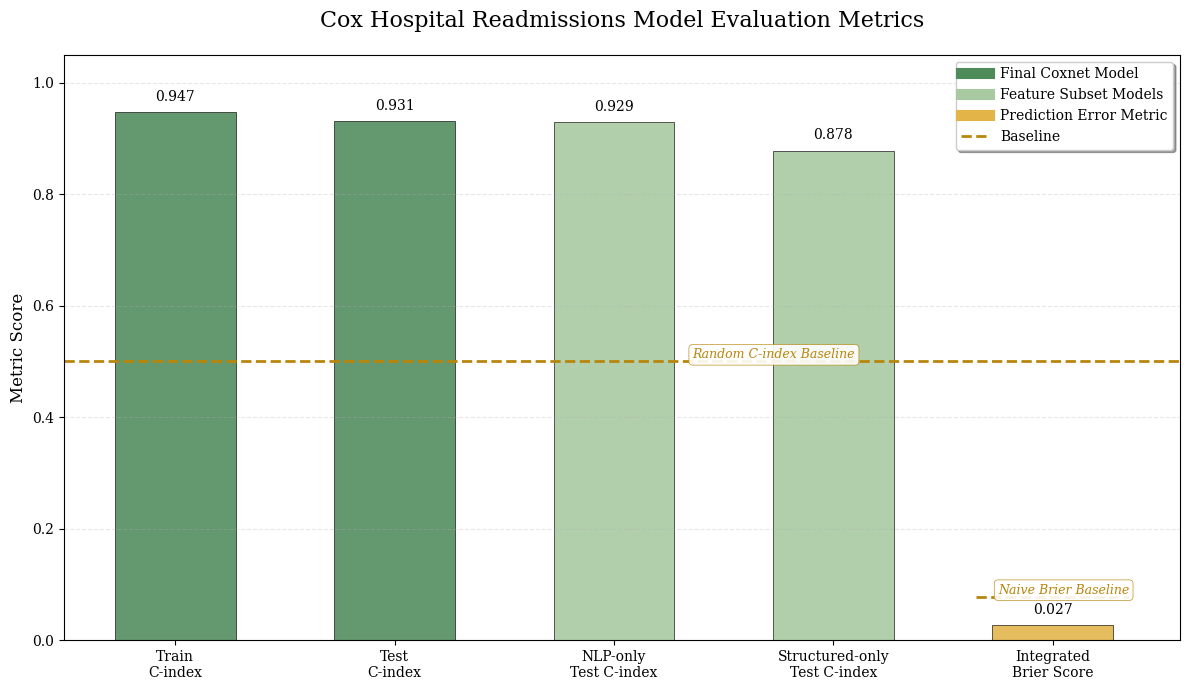

In [70]:
# Sets serif font globally for desired design aesthetic
plt.rcParams["font.family"] = ["serif"]
plt.rcParams["font.weight"] = "light"

# Stores final metric values
train_cindex = 0.947
test_cindex = 0.931
nlp_test_cindex = 0.929
structured_test_cindex = 0.878
integrated_brier = 0.027

# Stores final model evaluation metrics
metrics = {
    "Train\nC-index": train_cindex,
    "Test\nC-index": test_cindex,
    "NLP-only\nTest C-index": nlp_test_cindex,
    "Structured-only\nTest C-index": structured_test_cindex,
    "Integrated\nBrier Score": integrated_brier
}

# Extracts labels and values for plotting
metric_labels = list(metrics.keys())
metric_values = list(metrics.values())

# Defines bar chart positioning
x = np.arange(len(metric_labels))
width = 0.55

# Defines green and mustard color palette
green_main = "#4F8A5B"
green_light = "#A8C9A1"
mustard_main = "#B8860B"
mustard_light = "#E3B448"

# Assigns colors by metric type
bar_colors = [
    green_main,      # Final train C-index
    green_main,      # Final test C-index
    green_light,     # NLP-only comparison model
    green_light,     # Structured-only comparison model
    mustard_light    # Integrated Brier Score
]

# Calculates naive Brier baseline from test event rate
# This represents predicting the same readmission probability for every patient
brier_baseline = y_test_df["event"].mean() * (1 - y_test_df["event"].mean())

# Verifies that the naive Brier baseline is higher than the model's Brier score
print(f"Integrated Brier Score: {integrated_brier:.3f}")
print(f"Naive Brier Baseline: {brier_baseline:.3f}")

# Creates figure
fig, ax = plt.subplots(figsize=(12, 7))

# Plots model metric bars
bars = ax.bar(
    x,
    metric_values,
    width,
    color=bar_colors,
    alpha=0.88,
    edgecolor="black",
    linewidth=0.5
)

# Adds random C-index baseline
ax.axhline(
    0.5,
    color=mustard_main,
    linestyle="dashed",
    linewidth=2
)

ax.text(
    3.1,
    0.5,
    "Random C-index Baseline",
    ha="right",
    va="bottom",
    fontsize=9,
    fontweight="light",
    style="italic",
    color=mustard_main,
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        alpha=0.9,
        edgecolor=mustard_main,
        linewidth=0.5
    )
)

# Adds naive Brier baseline only over the Brier score bar
# Since Brier score is lower-is-better, this line should sit above the actual Brier bar
ax.hlines(
    brier_baseline,
    xmin=3.65,
    xmax=4.35,
    color=mustard_main,
    linestyle="dashed",
    linewidth=2
)

ax.text(
    4.35,
    brier_baseline,
    "Naive Brier Baseline",
    ha="right",
    va="bottom",
    fontsize=9,
    fontweight="light",
    style="italic",
    color=mustard_main,
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        alpha=0.9,
        edgecolor=mustard_main,
        linewidth=0.5
    )
)

# Adds metric values above each bar
for bar, value in zip(bars, metric_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.015,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="light"
    )

# Formats axes and title
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=10)
ax.set_ylabel("Metric Score", fontsize=12)
ax.set_ylim(0, 1.05)

ax.set_title(
    "Cox Hospital Readmissions Model Evaluation Metrics",
    fontsize=16,
    fontweight="light",
    pad=20
)

ax.grid(axis="y", alpha=0.3, linestyle="--")

# Creates shared legend
legend_elements = [
    Line2D([0], [0], color=green_main, lw=8, label="Final Coxnet Model"),
    Line2D([0], [0], color=green_light, lw=8, label="Feature Subset Models"),
    Line2D([0], [0], color=mustard_light, lw=8, label="Prediction Error Metric"),
    Line2D([0], [0], color=mustard_main, lw=2, linestyle="dashed", label="Baseline")
]

ax.legend(
    handles=legend_elements,
    loc="upper right",
    frameon=True,
    fancybox=True,
    shadow=True
)

plt.tight_layout()
plt.savefig(
    "cox_hospital_readmissions_model_metrics.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

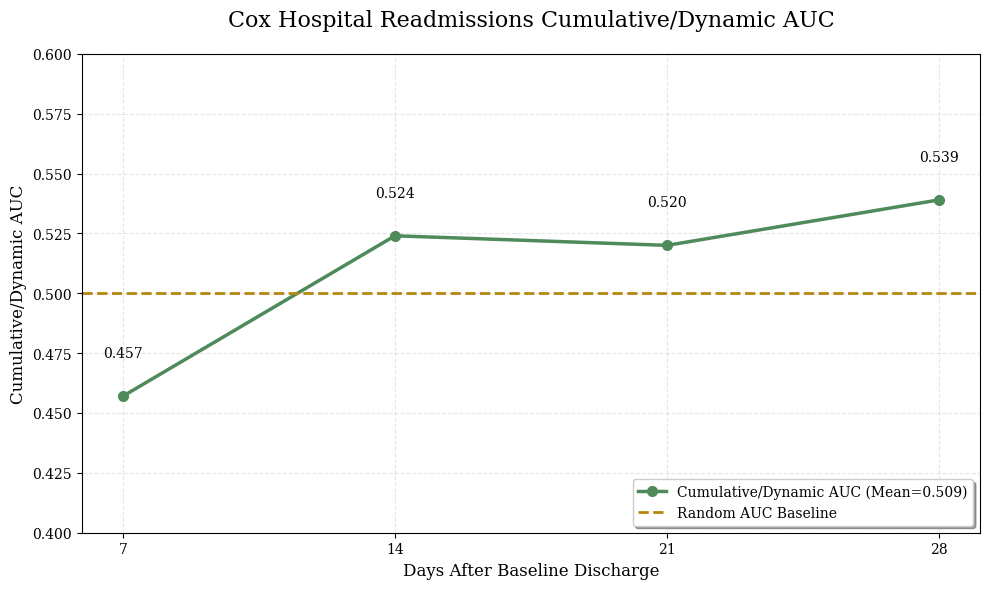

In [71]:
# Sets serif font globally for desired design aesthetic
plt.rcParams["font.family"] = ["serif"]
plt.rcParams["font.weight"] = "light"

# Stores cumulative/dynamic AUC values
auc_days = np.array([7, 14, 21, 28])
auc_values = np.array([0.457, 0.524, 0.520, 0.539])
mean_auc = 0.509

# Defines green and mustard color palette
green_main = "#4F8A5B"
green_light = "#A8C9A1"
mustard_main = "#B8860B"
mustard_light = "#E3B448"

# Creates figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plots cumulative/dynamic AUC curve
ax.plot(
    auc_days,
    auc_values,
    color=green_main,
    linewidth=2.5,
    marker="o",
    markersize=7,
    label=f"Cumulative/Dynamic AUC (Mean={mean_auc:.3f})"
)

# Adds random AUC baseline
ax.axhline(
    0.5,
    color=mustard_main,
    linewidth=2,
    linestyle="dashed",
    label="Random AUC Baseline"
)

# Adds value labels to each point
for day, auc in zip(auc_days, auc_values):
    ax.text(
        day,
        auc + 0.015,
        f"{auc:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="light"
    )

# Formats axes and title
ax.set_title(
    "Cox Hospital Readmissions Cumulative/Dynamic AUC",
    fontsize=16,
    fontweight="light",
    pad=20
)

ax.set_xlabel("Days After Baseline Discharge", fontsize=12)
ax.set_ylabel("Cumulative/Dynamic AUC", fontsize=12)

ax.set_xticks(auc_days)
ax.set_ylim(0.40, 0.60)

ax.grid(alpha=0.3, linestyle="--")

ax.legend(
    loc="lower right",
    frameon=True,
    fancybox=True,
    shadow=True
)

plt.tight_layout()
plt.savefig(
    "cox_hospital_readmissions_auc_curve.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

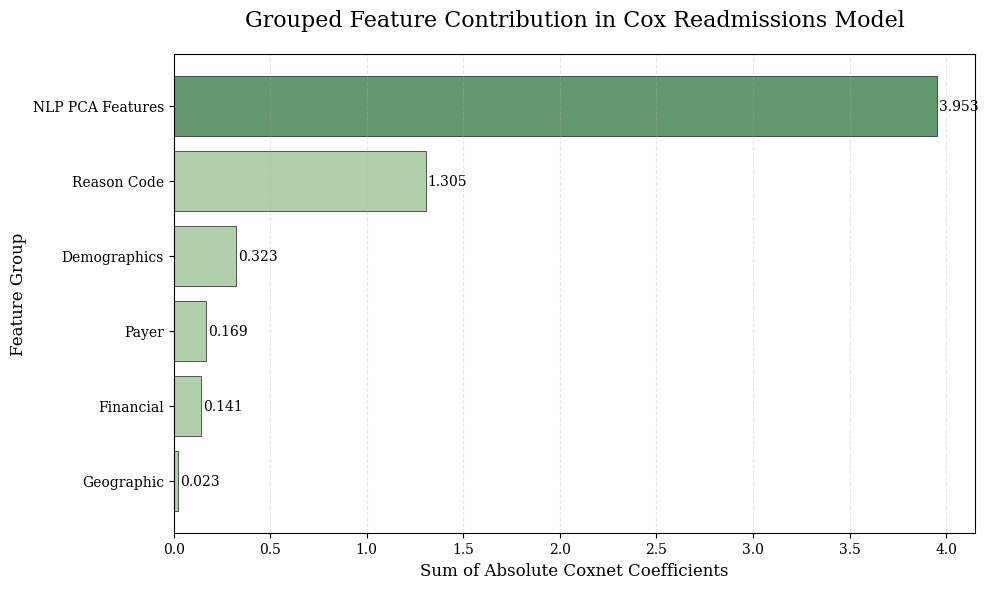

In [73]:
# Extracts Coxnet coefficients from final fitted model
coef_values = coxnet_model_brier.coef_

# If Coxnet stores coefficients across multiple alphas, use the final alpha column
if coef_values.ndim > 1:
    coef_values = coef_values[:, -1]

coef_df = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coefficient": coef_values
})

# Uses absolute coefficient size as a rough measure of feature contribution
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

# Groups features into interpretable categories
def assign_feature_group(feature):
    if feature.startswith("pca_"):
        return "NLP PCA Features"
    elif feature in ["age", "gender_M"]:
        return "Demographics"
    elif feature.startswith(("race_", "ethnicity_", "marital_", "gender_")):
        return "Demographics"
    elif feature in ["total_claim_cost", "payer_coverage"]:
        return "Financial"
    elif feature in ["lat", "lon"]:
        return "Geographic"
    elif feature.startswith("payer_"):
        return "Payer"
    elif feature.startswith("reasoncode_"):
        return "Reason Code"
    else:
        return "Other"

coef_df["feature_group"] = coef_df["feature"].apply(assign_feature_group)

# Aggregates absolute coefficient magnitude by feature group
group_importance = (
    coef_df
    .groupby("feature_group", as_index=False)["abs_coefficient"]
    .sum()
    .sort_values("abs_coefficient", ascending=True)
)

# Sets serif font globally for desired design aesthetic
plt.rcParams["font.family"] = ["serif"]
plt.rcParams["font.weight"] = "light"

# Defines green and mustard color palette
green_main = "#4F8A5B"
green_light = "#A8C9A1"
mustard_main = "#B8860B"
mustard_light = "#E3B448"

bar_colors = [
    green_light if group != "NLP PCA Features" else green_main
    for group in group_importance["feature_group"]
]

# Creates horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    group_importance["feature_group"],
    group_importance["abs_coefficient"],
    color=bar_colors,
    alpha=0.88,
    edgecolor="black",
    linewidth=0.5
)

# Adds value labels
for bar in bars:
    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.3f}",
        va="center",
        fontsize=10,
        fontweight="light"
    )

ax.set_title(
    "Grouped Feature Contribution in Cox Readmissions Model",
    fontsize=16,
    fontweight="light",
    pad=20
)

ax.set_xlabel("Sum of Absolute Coxnet Coefficients", fontsize=12)
ax.set_ylabel("Feature Group", fontsize=12)
ax.grid(axis="x", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig(
    "grouped_feature_contribution_cox_model.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

Feature contribution was estimated using the summed absolute Coxnet coefficients by feature group. Because coefficients are model-based and not causal, these values should be interpreted as relative predictive contribution rather than causal importance.

## Conclusion
Although the original proposal described using hazard ratios to create low, medium, and high risk tiers, the final model used a penalized Cox model because the unpenalized Cox model produced a singular matrix. The final risk-tier analysis supports the model’s practical value. Patients in the high-risk tier had a much higher observed readmission rate than patients in the low- and medium-risk tiers, suggesting that the model could help identify patients who may benefit from additional discharge planning or follow-up support.

In [74]:
# Predict risk scores for test patients
test_risk_scores = coxnet_model_brier.predict(X_test_scaled)

# Adds risk scores back to test dataframe
risk_df = test_df.copy()
risk_df["risk_score"] = test_risk_scores

# Creates low, medium, and high risk tiers based on tertiles
risk_df["risk_tier"] = pd.qcut(
    risk_df["risk_score"],
    q=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# Checks event rate by risk tier
tier_summary = (
    risk_df
    .groupby("risk_tier", observed=True)
    .agg(
        patients=("patient", "count"),
        readmissions=("event", "sum"),
        event_rate=("event", "mean"),
        avg_risk_score=("risk_score", "mean")
    )
    .reset_index()
)

print(tier_summary)

     risk_tier  patients  readmissions  event_rate  avg_risk_score
0     Low Risk       786             1    0.001272       -1.413991
1  Medium Risk       786             5    0.006361       -0.366087
2    High Risk       787           195    0.247776        1.757146


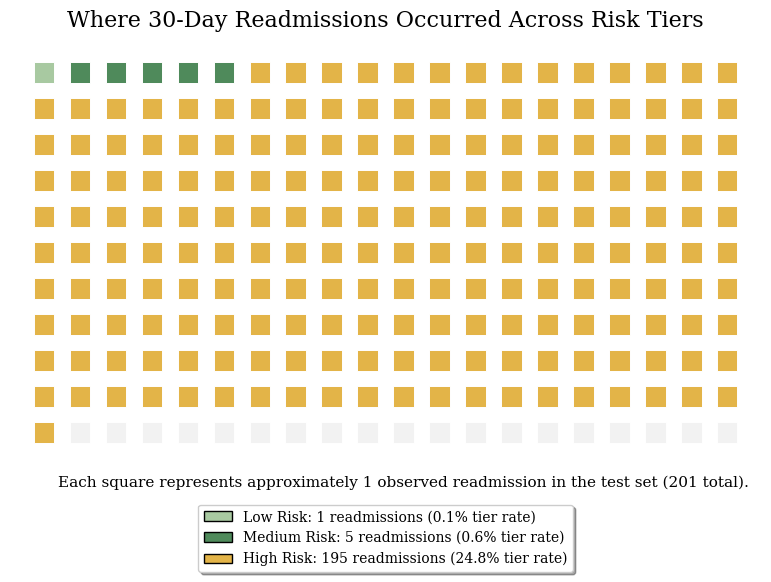

In [78]:
# Sets serif font globally for desired design aesthetic
plt.rcParams["font.family"] = ["serif"]
plt.rcParams["font.weight"] = "light"

# Summarizes readmissions by risk tier
waffle_df = (
    risk_df
    .groupby("risk_tier", observed=True)
    .agg(readmissions=("event", "sum"))
    .reset_index()
)

# Ensures risk tiers stay in the intended order
tier_order = ["Low Risk", "Medium Risk", "High Risk"]
waffle_df["risk_tier"] = pd.Categorical(
    waffle_df["risk_tier"],
    categories=tier_order,
    ordered=True
)
waffle_df = waffle_df.sort_values("risk_tier")

# Defines number of waffle squares
# Each square represents approximately one observed readmission
total_readmissions = int(waffle_df["readmissions"].sum())
grid_cols = 20
grid_rows = int(np.ceil(total_readmissions / grid_cols))
total_squares = grid_cols * grid_rows

# Defines green and mustard color palette
low_color = "#A8C9A1"
medium_color = "#4F8A5B"
high_color = "#E3B448"

tier_colors = {
    "Low Risk": low_color,
    "Medium Risk": medium_color,
    "High Risk": high_color
}
# Expands readmission counts into one color per waffle square
square_tiers = []
for _, row in waffle_df.iterrows():
    square_tiers.extend([row["risk_tier"]] * int(row["readmissions"]))

# Pads remaining empty spaces if grid is not perfectly rectangular
square_tiers.extend(["Empty"] * (total_squares - len(square_tiers)))

# Converts square list into grid coordinates
x_vals = []
y_vals = []
colors = []

for i, tier in enumerate(square_tiers):
    x_vals.append(i % grid_cols)
    y_vals.append(grid_rows - 1 - (i // grid_cols))
    colors.append(tier_colors.get(tier, "#F2F2F2"))

# Creates figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plots waffle squares
ax.scatter(
    x_vals,
    y_vals,
    c=colors,
    marker="s",
    s=220,
    edgecolor="white",
    linewidth=0.7
)

# Removes chart clutter
ax.set_aspect("equal")
ax.axis("off")

# Adds title
ax.set_title(
    "Where 30-Day Readmissions Occurred Across Risk Tiers",
    fontsize=16,
    fontweight="light",
    pad=20
)

# Adds subtitle-style annotation
ax.text(
    grid_cols / 2,
    -1.4,
    f"Each square represents approximately 1 observed readmission in the test set ({total_readmissions:,} total).",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="light"
)

# Creates legend with readmission counts and rates
legend_elements = []
for _, row in waffle_df.iterrows():
    tier = row["risk_tier"]
    readmissions = int(row["readmissions"])
    event_rate = risk_df.loc[risk_df["risk_tier"] == tier, "event"].mean() * 100
    
    legend_elements.append(
        Patch(
            facecolor=tier_colors[tier],
            edgecolor="black",
            label=f"{tier}: {readmissions} readmissions ({event_rate:.1f}% tier rate)"
        )
    )

ax.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=1,
    frameon=True,
    fancybox=True,
    shadow=True
)

plt.tight_layout()
plt.savefig(
    "readmission_risk_tier_waffle_chart.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()